In [ ]:
pip install statsbomb

In [ ]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 5.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import statsbomb as sb
import matplotlib.pyplot as plt


from mplsoccer import VerticalPitch
from mplsoccer import Pitch, Sbopen

In [ ]:
events = sb.Events(event_id='22912')

In [ ]:
events

Events data for ID: 22912

In [ ]:
df = events.get_dataframe(event_type='shot')

/usr/local/lib/python3.13/dist-packages/statsbomb/parser.py:86: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[name_cols] = df[name_cols].applymap(get_event_name)


In [ ]:
df.head()

,event_type,id,index,period,timestamp,minute,second,possession,possession_team,play_pattern,...,follows_dribble,redirect,one_on_one,open_goal,deflected,start_location_x,start_location_y,end_location_x,end_location_y,end_location_z
0,shot,ea96e2b2-af1e-4157-a700-5919a9c075dc,34,1,00:01:48.568,1,48,3,Liverpool,Other,...,None,None,None,None,None,108.2,40.1,120.0,42.5,0.9
1,shot,67b9cbde-0eb7-4800-9bfe-c2ce1ad406a6,342,1,00:09:04.723,9,4,15,Tottenham Hotspur,Regular Play,...,None,None,None,None,None,91.9,43.1,120.0,46.5,5.2
2,shot,08c3746b-a125-4adb-991e-c8053578451a,587,1,00:16:48.573,16,48,25,Liverpool,From Throw In,...,None,None,None,None,None,90.2,59.3,120.0,34.7,0.8
3,shot,8fb3106d-10fb-42c6-bcf6-2ea34c7ff9a3,758,1,00:20:31.085,20,31,35,Liverpool,From Keeper,...,None,None,None,None,None,95.2,47.2,99.7,46.2,NaN
4,shot,4004264d-14a1-4e0d-b01d-a5d025e26c17,768,1,00:21:53.381,21,53,37,Liverpool,From Throw In,...,None,None,None,None,None,113.0,59.5,113.2,0.1,NaN


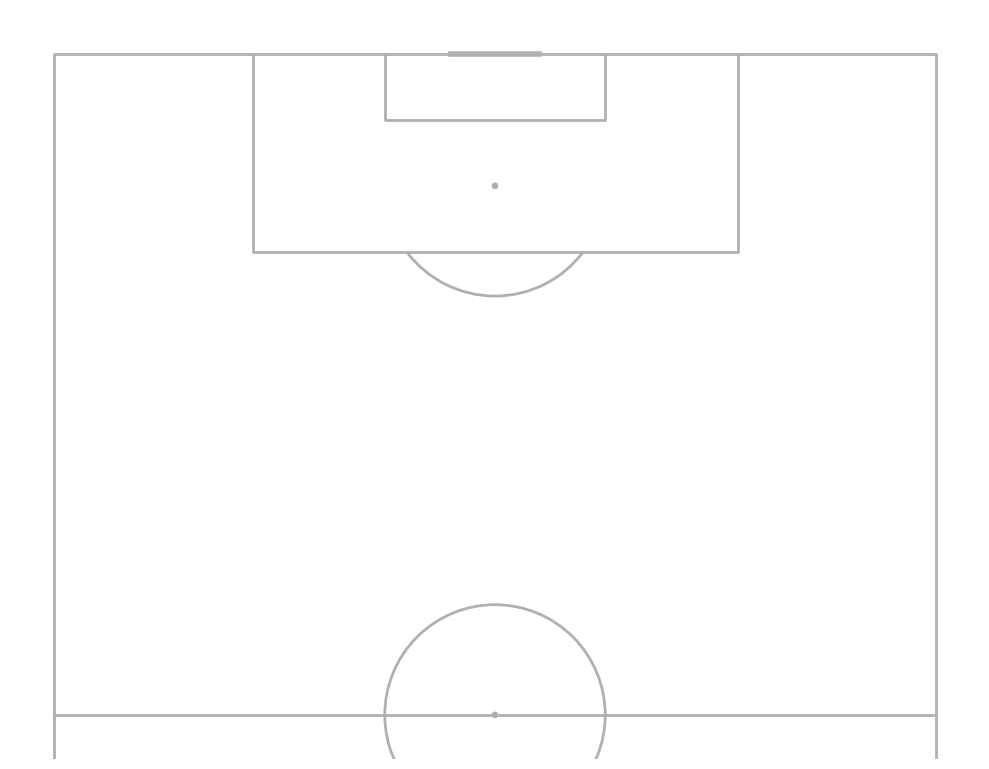

In [ ]:
pitch = VerticalPitch(
    half=True
)
fig, ax = pitch.draw(figsize=(10, 8))

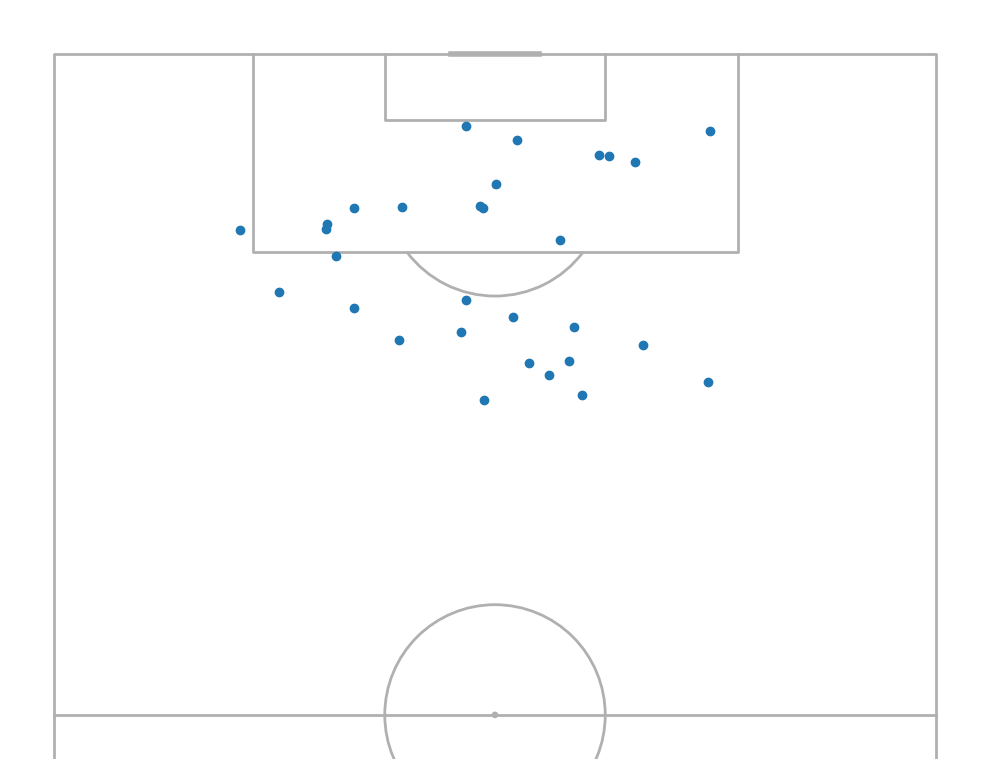

In [ ]:
pitch = VerticalPitch(
    half=True
)
fig, ax = pitch.draw(figsize=(10, 8))
sc = pitch.scatter(df["start_location_x"], df["start_location_y"],
                   ax=ax)

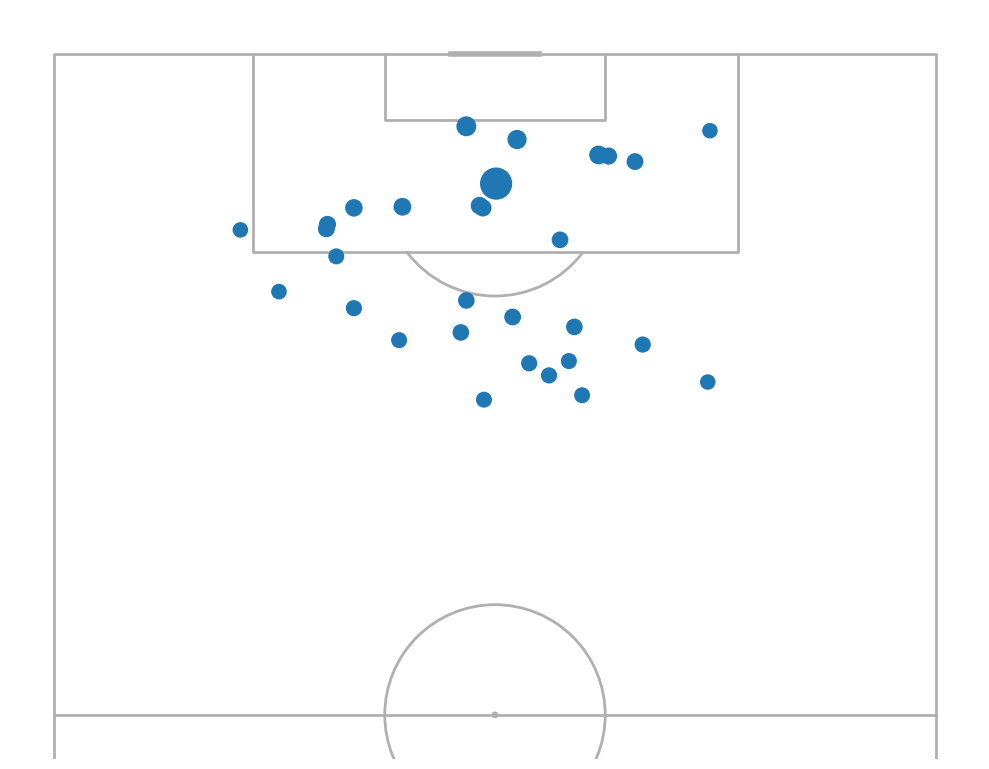

In [ ]:
pitch = VerticalPitch(
    half=True
)
fig, ax = pitch.draw(figsize=(10, 8))
sc = pitch.scatter(df["start_location_x"], df["start_location_y"],
                   s=df["statsbomb_xg"]*500+100,
                   ax=ax)

In [ ]:
liverpool_color = "#FF6347"

In [ ]:
liverpool_df = df[df["team"] == "Liverpool"].copy()

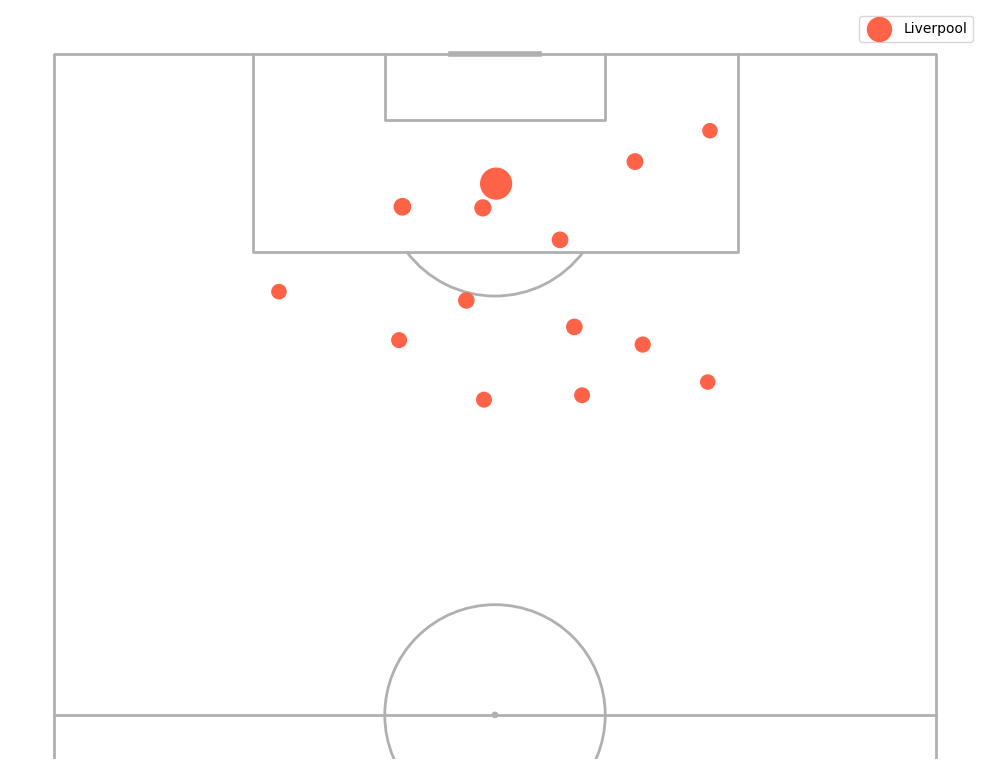

In [ ]:
pitch = VerticalPitch(
    half=True
)
fig, ax = pitch.draw(figsize=(10, 8))
liverpool_sc = pitch.scatter(liverpool_df["start_location_x"], liverpool_df["start_location_y"],
                             s=liverpool_df["statsbomb_xg"]*500+100,
                             c=liverpool_color,
                             ax=ax,
                             label='Liverpool')
ax.legend()

In [ ]:
parser = Sbopen()
df, related, freeze, tactics = parser.event(22912)

In [ ]:
sub = df.loc[df["type_name"] == "Substitution"].loc[df["team_name"] == "Liverpool"].iloc[0]["index"]
mask_cdm = (df.type_name == 'Pass') & (df.team_name == "Liverpool") & (df.index < sub) & (df.outcome_name.isnull())
df_pass = df.loc[mask_cdm, ['x', 'y', 'end_x', 'end_y', "player_name", "pass_recipient_name"]]
df_pass["player_name"] = df_pass["player_name"].apply(lambda x: str(x).split()[-1])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].apply(lambda x: str(x).split()[-1])

In [ ]:
scatter_df = pd.DataFrame()
for i, name in enumerate (df_pass["player_name"].unique()):
  passx = df_pass.loc[df_pass["player_name"] == name] ["x"].to_numpy()
  recx = df_pass.loc[df_pass["pass_recipient_name"] == name] ["end_x"].to_numpy()
  passy = df_pass.loc[df_pass["player_name"] == name] ["y"].to_numpy()
  recy = df_pass.loc[df_pass["pass_recipient_name"] == name] ["end_y"].to_numpy()
  scatter_df.at[i, "player_name"] = name

  scatter_df.at[i, "x"] = np.mean(np.concatenate( [passx, recx]))
  scatter_df.at[i, "y"] = np.mean(np.concatenate( [passy, recy]))

  scatter_df.at[i, "no"] = df_pass.loc[df_pass["player_name"] == name].count().iloc[0]

scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max() * 1500)

In [ ]:
df_pass["pair_key"] = df_pass.apply(lambda x: "_".join(sorted([x["player_name"], x["pass_recipient_name"]])), axis=1)
lines_df = df_pass.groupby(["pair_key"]).x.count().reset_index()
lines_df.rename({'x':'pass_count'}, axis='columns', inplace=True)

lines_df = lines_df[lines_df['pass_count']>2]

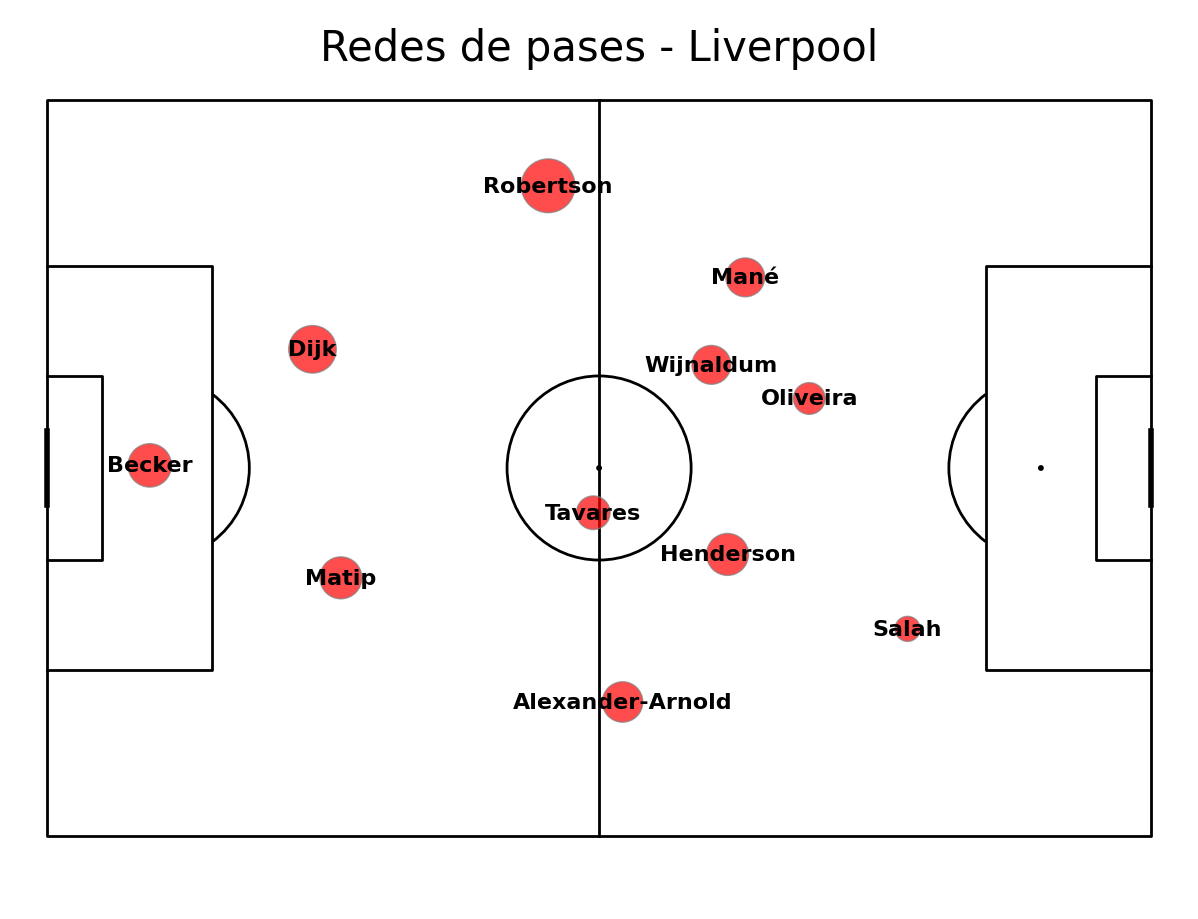

In [ ]:
pitch = Pitch(line_color='black')

fig, ax = pitch.grid(
    grid_height=0.9,
    title_height=0.06,
    axis=False,
    endnote_height=0.04,
    title_space=0,
    endnote_space=0
)

pitch.scatter(
    scatter_df.x,
    scatter_df.y,
    s=scatter_df.marker_size,
    color='red',
    edgecolors='grey',
    linewidth=1,
    alpha=0.7,
    ax=ax['pitch']
)

for i, row in scatter_df.iterrows():
    pitch.annotate(
        row.player_name,
        xy=(row.x, row.y),
        c='black',
        va='center',
        ha='center',
        weight='bold',
        size=16,
        ax=ax['pitch']
    )

fig.suptitle("Redes de pases - Liverpool", fontsize=30)

plt.show()

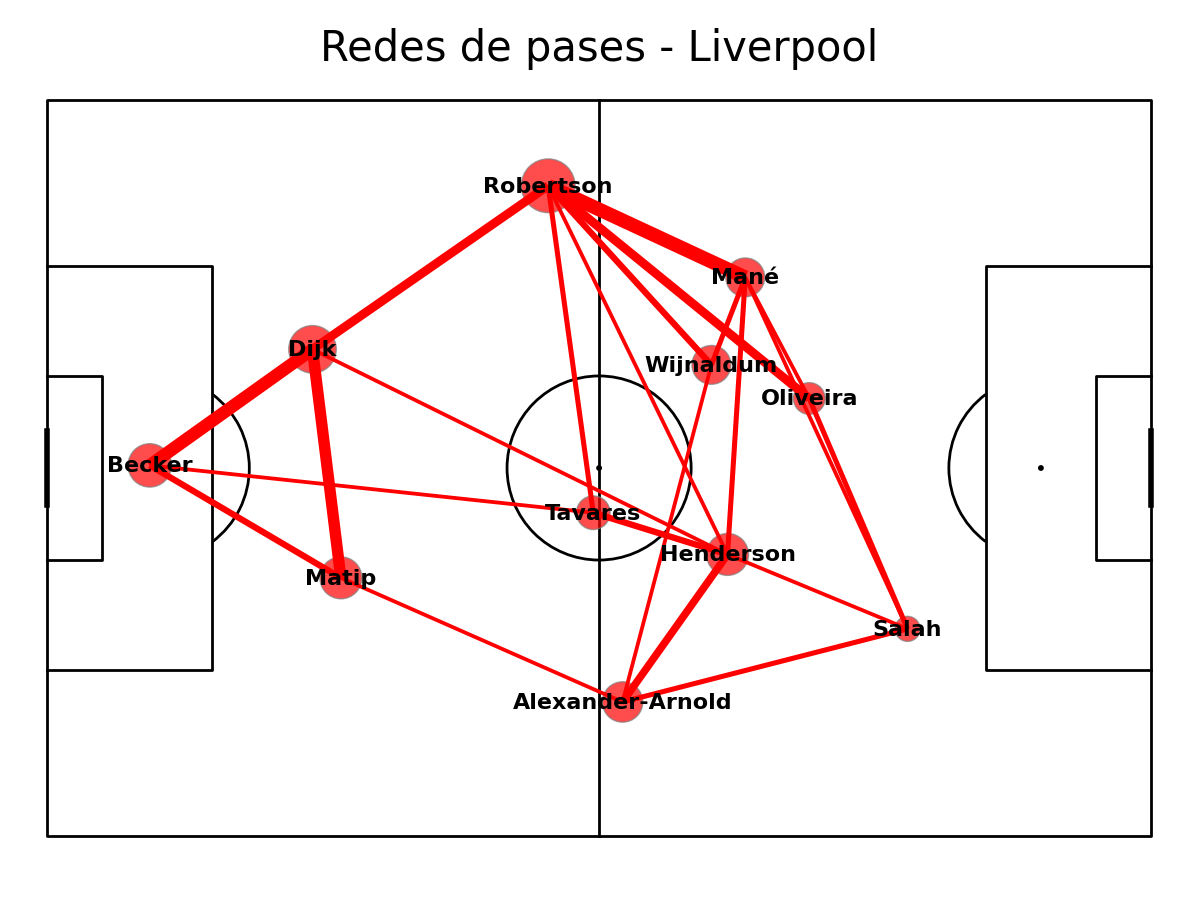

In [22]:
pitch = Pitch(line_color='black')

fig, ax = pitch.grid(
    grid_height=0.9,
    title_height=0.06,
    axis=False,
    endnote_height=0.04,
    title_space=0,
    endnote_space=0
)

pitch.scatter(
    scatter_df.x,
    scatter_df.y,
    s=scatter_df.marker_size,
    color='red',
    edgecolors='grey',
    linewidth=1,
    alpha=0.7,
    ax=ax['pitch']
)

for i, row in scatter_df.iterrows():
    pitch.annotate(
        row.player_name,
        xy=(row.x, row.y),
        c='black',
        va='center',
        ha='center',
        weight='bold',
        size=16,
        ax=ax['pitch']
    )

for i, row in lines_df.iterrows():
  player1 = row["pair_key"].split("_")[0]
  player2 = row["pair_key"].split("_")[1]

  player1_x = scatter_df.loc[scatter_df["player_name"] == player1]['x'].iloc[0]
  player1_y = scatter_df.loc[scatter_df["player_name"] == player1]['y'].iloc[0]
  player2_x = scatter_df.loc[scatter_df["player_name"] == player2]['x'].iloc[0]
  player2_y = scatter_df.loc[scatter_df["player_name"] == player2]['y'].iloc[0]
  num_passes = row["pass_count"]

  line_width = (num_passes / lines_df['pass_count'].max() * 10)

  pitch.lines(player1_x, player1_y, player2_x, player2_y,
              alpha=1, lw=line_width, zorder=2, color="red", ax = ax["pitch"])

fig.suptitle("Redes de pases - Liverpool", fontsize=30)

plt.show()